In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv("../data/VCB_data.csv")

# 2. Tạo các cột biến trễ (Lag) và biến mục tiêu (Target) nếu chưa có
if "Close_Lag1" not in df.columns:
    df["Close_Lag1"] = df["Close"].shift(1)
if "Close_Lag2" not in df.columns:
    df["Close_Lag2"] = df["Close"].shift(2)
if "Next_Day_Close" not in df.columns:
    df["Next_Day_Close"] = df["Close"].shift(-1)

# 3. Lọc bỏ các dòng chứa giá trị khuyết (NaN) do shift tạo ra
cols_needed = [
    "Close",
    "Volume",
    "RSI",
    "Close_Lag1",
    "Close_Lag2",
    "Next_Day_Close",
]
df_clean = df.dropna(subset=cols_needed)

Hình 1 — Biểu đồ phân phối (Distribution Plots)

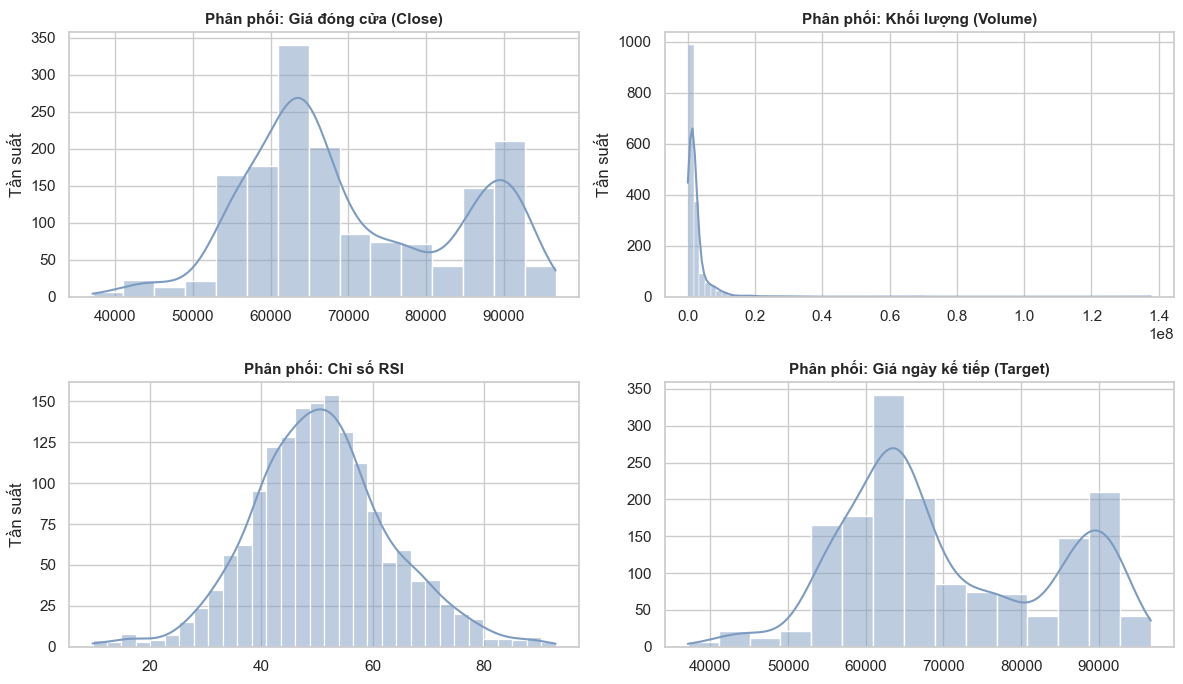

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Subplot 1: Giá đóng cửa (Close)
sns.histplot(
    data=df_clean, x="Close", kde=True, ax=axes[0, 0], color="#7D9BC1"
)
axes[0, 0].set_title(
    "Phân phối: Giá đóng cửa (Close)", fontsize=11, fontweight="bold"
)
axes[0, 0].set_ylabel("Tần suất")
axes[0, 0].set_xlabel("")

# Subplot 2: Khối lượng (Volume)
sns.histplot(
    data=df_clean, x="Volume", kde=True, ax=axes[0, 1], color="#7D9BC1"
)
axes[0, 1].set_title(
    "Phân phối: Khối lượng (Volume)", fontsize=11, fontweight="bold"
)
axes[0, 1].set_ylabel("Tần suất")
axes[0, 1].set_xlabel("")

# Subplot 3: Chỉ số RSI
sns.histplot(data=df_clean, x="RSI", kde=True, ax=axes[1, 0], color="#7D9BC1")
axes[1, 0].set_title("Phân phối: Chỉ số RSI", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Tần suất")
axes[1, 0].set_xlabel("")

# Subplot 4: Giá ngày kế tiếp (Next_Day_Close)
sns.histplot(
    data=df_clean, x="Next_Day_Close", kde=True, ax=axes[1, 1], color="#7D9BC1"
)
axes[1, 1].set_title(
    "Phân phối: Giá ngày kế tiếp (Target)", fontsize=11, fontweight="bold"
)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()

Hình 2 — Biểu đồ tán xạ & Đường hồi quy (Scatter & Regression Plots)

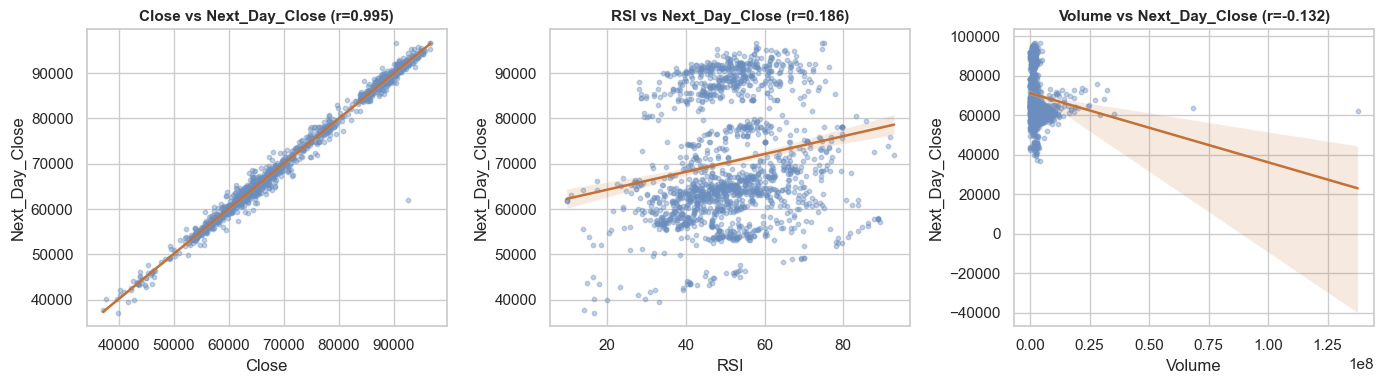

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

features = ["Close", "RSI", "Volume"]

for i, col in enumerate(features):
    # Tính hệ số tương quan Pearson r
    r_val = df_clean[col].corr(df_clean["Next_Day_Close"])

    # Vẽ scatter plot kèm đường hồi quy
    sns.regplot(
        data=df_clean,
        x=col,
        y="Next_Day_Close",
        ax=axes[i],
        scatter_kws={"s": 10, "alpha": 0.4, "color": "#6B8EBE"},
        line_kws={"color": "#C47135", "linewidth": 1.8},
    )

    axes[i].set_title(
        f"{col} vs Next_Day_Close (r={r_val:.3f})", fontsize=11, fontweight="bold"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Next_Day_Close")

plt.tight_layout()
plt.show()

Hình 3 — Ma trận tương quan Pearson (Heatmap)

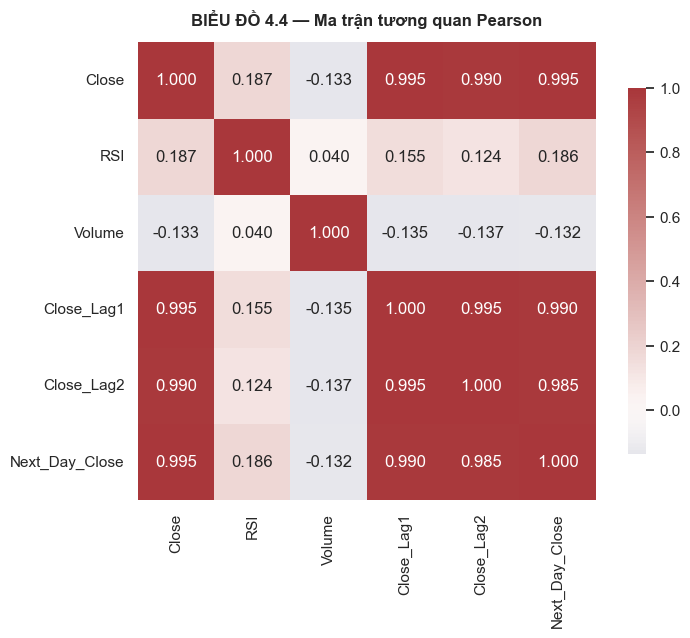

In [5]:
cols_corr = [
    "Close",
    "RSI",
    "Volume",
    "Close_Lag1",
    "Close_Lag2",
    "Next_Day_Close",
]
corr_matrix = df_clean[cols_corr].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="vlag",  # Bảng màu tương tự hình mẫu (từ xanh nhạt đến nâu đỏ)
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "BIỂU ĐỒ 4.4 — Ma trận tương quan Pearson",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()